# **Which Customers to Target**

_This data project has been used as a take-home assignment in the recruitment process for the data science positions at Starbucks._

Assignment
----------

**Background**

In the experiment simulated by the data, an advertising promotion was tested to see if it would bring more customers to purchase a specific product priced at $10. Since it costs the company $0.15 to send out each promotion, it would be best to limit that promotion only to those that are most receptive to the promotion.

**Task**

1.  Analyze the results of the experiment and identify the effect of the Treatment on product purchase and Net Incremental Revenue;
2.  Build a model to select the best customers to target that maximizes the Incremental Response Rate and Net Incremental Revenue;
3.  Score the `Test.csv` using the model and select the best customers and share the customer ID’s as csv file;
4.  Explain briefly the approach used in a separate document and also share the code that can be executed to reproduce results.

Data Description
----------------

A randomized experiment was conducted and the results are in `Training.csv`:

*   `Treatment` – Indicates if the customer was part of treatment or control
*   `Purchase` – Indicates if the customer purchased the product
*   `ID` – Customer ID
*   `V1` to `V7` – features of the customer

Cost of sending a Promotion: $0.15 Revenue from purchase of product: $10 (There is only one product)

Practicalities
--------------

### Tips

*   **Incremental Response Rate (IRR)**

IRR depicts how many more customers purchased the product with the promotion, as compared to if they didn't receive the promotion. Mathematically, it's the ratio of the number of purchasers in the promotion group to the total number of customers in the purchasers group (_treatment_) minus the ratio of the number of purchasers in the non-promotional group to the total number of customers in the non-promotional group (_control_).

IRR\=purchtreatcusttreat−ctrltreatcustctrlIRR = \\frac{purch\_{treat}}{cust\_{treat}} - \\frac{ctrl\_{treat}}{cust\_{ctrl}}IRR\=custtreat​purchtreat​​−custctrl​ctrltreat​​

*   **Net Incremental Revenue (NIR)**

NIR depicts how much is made (or lost) by sending out the promotion. Mathematically, this is 10 times the total number of purchasers that received the promotion minus 0.15 times the number of promotions sent out, minus 10 times the number of purchasers who were not given the promotion.

NIR\=(10×purchtreat−0.15×custtreat)−10×purchctrlNIR = (10 \\times purch\_{treat} - 0.15 \\times cust\_{treat}) - 10 \\times purch\_{ctrl}NIR\=(10×purchtreat​−0.15×custtreat​)−10×purchctrl​

*   **How To Test Your Strategy?**

When you feel like you have an optimization strategy, complete the `promotion_strategy` function to pass to the `test_results` function.  
From past data, we know there are four possible outomes:

Table of actual promotion vs. predicted promotion customers:

                Actual
    Predicted  Yes   No
       Yes      I    II
       No      III   IV
    

The metrics are only being compared for the individuals we predict should obtain the promotion – that is, quadrants I and II. Since the first set of individuals that receive the promotion (in the training set) receive it randomly, we can expect that quadrants I and II will have approximately equivalent participants.

Comparing quadrant I to II then gives an idea of how well your promotion strategy will work in the future.

Get started by reading in the data below. See how each variable or combination of variables along with a promotion influences the chance of purchasing. When you feel like you have a strategy for who should receive a promotion, test your strategy against the test dataset used in the final `test_results` function.

## Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from yellowbrick.model_selection import FeatureImportances


train_data = pd.read_csv('datasets/Training.csv')
test_data = pd.read_csv('datasets/Test.csv')

In [2]:
train_data.head(10)

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,1,No,0,2,30.443518,-1.165083,1,1,3,2
1,3,No,0,3,32.159350,-0.645617,2,3,2,2
2,4,No,0,2,30.431659,0.133583,1,1,4,2
3,5,No,0,0,26.588914,-0.212728,2,1,4,2
4,8,Yes,0,3,28.044331,-0.385883,1,1,2,2
5,9,No,0,1,41.189415,-0.905350,2,4,4,1
6,11,No,0,1,40.690409,1.085939,2,2,1,2
7,14,No,0,2,25.971529,-1.424817,1,3,3,2
8,15,Yes,0,2,31.930423,0.393317,2,3,1,2
9,16,No,0,1,27.474650,0.566472,2,2,3,2


In [3]:
test_data.head(10)

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,2,No,0,1,41.376390,1.172517,1,1,2,2
1,6,Yes,0,1,25.163598,0.653050,2,2,2,2
2,7,Yes,0,1,26.553778,-1.597972,2,3,4,2
3,10,No,0,2,28.529691,-1.078506,2,3,2,2
4,12,No,0,2,32.378538,0.479895,2,2,1,2
5,13,Yes,0,0,32.566788,-1.684550,2,1,2,1
6,19,No,0,2,29.833921,-1.078506,1,2,3,2
7,26,No,0,3,20.481525,1.345672,2,3,1,2
8,29,Yes,0,2,25.410573,-1.338239,2,1,4,2
9,32,No,0,0,27.868464,-0.905350,2,1,2,2


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84534 entries, 0 to 84533
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         84534 non-null  int64  
 1   Promotion  84534 non-null  object 
 2   purchase   84534 non-null  int64  
 3   V1         84534 non-null  int64  
 4   V2         84534 non-null  float64
 5   V3         84534 non-null  float64
 6   V4         84534 non-null  int64  
 7   V5         84534 non-null  int64  
 8   V6         84534 non-null  int64  
 9   V7         84534 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 6.4+ MB


## Analyze Incremental Metrics

In [5]:
baseline_conversion_rate = 0.05  # Example: Control group's response rate
promotion_cost = 0.15  # Cost to send the promotion
purchase_revenue = 10  # Revenue per purchase

treatment_data = train_data[train_data['Promotion'] == "Yes"]
control_data = train_data[train_data['Promotion'] == "No"]

IRR = (treatment_data['purchase'].mean() - control_data['purchase'].mean()) / baseline_conversion_rate
print(f"Incremental Response Rate (IRR): {IRR:.4f}")

Incremental Response Rate (IRR): 0.1891


In [6]:
cust_treat = len(treatment_data)
purch_treat = treatment_data['purchase'].sum()

cust_ctrl = len(control_data)
purch_ctrl = control_data['purchase'].sum()

# Net Incremental Revenue (NIR)
NIR = (purchase_revenue * purch_treat - promotion_cost * cust_treat) - (purchase_revenue * purch_ctrl)
print(f"Net Incremental Revenue (NIR): ${NIR:.2f}")

Net Incremental Revenue (NIR): $-2334.60


**Incremental Response Rate (IRR): 0.1891**
  - The Incremental Response Rate (IRR) of 0.1891 indicates that the treatment group (customers who received the promotion) experienced an increase in purchase behavior by approximately 18.91% compared to the control group (customers who did not receive the promotion).
  - This suggests that the promotion had a positive effect on customer purchases, leading to an uplift in the response rate.

**Net Incremental Revenue (NIR): -$2334.60**
  - The Net Incremental Revenue (NIR) is negative, with a value of -$2334.60. This indicates that, despite the increase in purchase behavior observed in the treatment group (as indicated by the positive IRR), the overall revenue from the promotion did not outweigh the costs of running the promotion.
  - The costs associated with sending the promotion (promotion cost * number of treated customers) exceeded the additional revenue generated from the purchases in the treatment group.
  - Therefore, even though the promotion led to an increase in purchases, the promotion was not profitable, leading to a loss in net revenue.

**Key Takeaways**

- **Incremental Response Rate (IRR)**: The promotion was effective in increasing purchase behavior, as evidenced by an IRR of 18.91%. This indicates that the treatment group responded positively to the promotion, with more purchases than the control group.
  
- **Negative Net Incremental Revenue (NIR)**: Although the promotion increased purchases, the overall revenue from these purchases did not cover the cost of the promotion, resulting in a negative NIR of -$2334.60. This suggests that the promotion was not financially profitable at the current cost structure.

- **Promotion Costs vs. Purchases**: The promotion's high cost of $0.15 per customer and the additional purchases generated were not enough to offset the promotion's expenses, leading to a loss rather than a gain in net revenue.

#### Conclusion:
While the promotion succeeded in increasing the response rate (IRR), it did not generate enough additional revenue to cover the costs, resulting in a negative Net Incremental Revenue (NIR). This suggests that the promotion might need to be re-evaluated for profitability or adjusted (e.g., lowering promotion costs, improving targeting, or increasing the price of the promoted product) to ensure better financial outcomes.

## Building Predictve Model

### Feature Engineering (Standard Scaling)

In [7]:
X_train = train_data[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']]
y_train = train_data['purchase']

X_test = test_data[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']]
y_test = test_data['purchase']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

### Model Training and Evaluation

In [8]:
def feat_importance_plot(model_trn, model_name):
    if model_name not in ['sgd','support_vector_machine','gaussian_naive_bayes','k_nearest_neighbors','bagging','neural_network']:
        plt.figure(figsize=(10, 4))
        top_10_feat = FeatureImportances(model_trn, relative=False, topn=10)
        top_10_feat.fit(X_train_scaled, y_test)
        top_10_feat.show()
    else:
        print(f"No feature importance available for {model_name}")

def print_confusion_matrix_display(model, y_test, y_pred):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=model.classes_)
    disp.plot(values_format='d', cmap='Blues')
    ax = disp.ax_
    ax.grid(False)
    plt.show()

def plot_roc_curve(model, model_name, X_test, y_test):
    try:
        y_proba = model.predict_proba(X_test)

        plt.figure(figsize=(8, 6))

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

        # Customize plot
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'ROC Curve - {model_name}', fontsize=14)
        plt.legend(loc="lower right", fontsize=10)
        plt.grid(False)

        # Show plot
        plt.show()
        print('\n')

    except (AttributeError, NotImplementedError):
        print(f"\nNote: ROC curve not available for {model_name} (predict_proba not implemented)")
        return

def feat_importance_plot(model_trn, model_name):
    """Plot feature importance for supported classifiers."""
    # Models supporting feature importance
    models_with_importance = [
        'logistic_regression', 'decision_tree', 'random_forest',
        'gradient_boosting', 'linear_discriminant_analysis',
        'adaboost', 'extra_trees', 'XGBoost', 'CatBoost'
    ]

    if model_name in models_with_importance:
        plt.figure(figsize=(10, 4))

        # Special handling for tree-based models and linear models
        if hasattr(model_trn, 'feature_importances_'):
            importances = model_trn.feature_importances_
            features = X_train_scaled.columns
        elif hasattr(model_trn, 'coef_'):
            importances = np.abs(model_trn.coef_).flatten()
            features = X_train_scaled.columns
        else:
            print(f"No feature importance available for {model_name}")
            return

        # Sort and plot top 10 features
        indices = np.argsort(importances)[-10:]
        plt.barh([features[i] for i in indices], importances[indices])
        plt.xlabel('Feature Importance')
        plt.title(f'Top 10 Features - {model_name}')
        plt.show()
    else:
        print(f"No feature importance available for {model_name}")

Since it needs to calculate Incremental Metrics fort Optimized Targeting

In [9]:
def calculate_incremental_metrics(y_actual, y_pred, baseline_conversion_rate, promotion_cost, purchase_revenue):
    treated_group = (y_pred == 1)
    treated_positive_rate = y_actual[treated_group].mean()

    # IRR: Incremental Response Rate
    irr = treated_positive_rate - baseline_conversion_rate

    # NIR: Net Incremental Revenue
    treated_count = treated_group.sum()
    revenue_from_treatment = treated_count * treated_positive_rate * purchase_revenue
    cost_of_treatment = treated_count * promotion_cost
    nir = revenue_from_treatment - cost_of_treatment

    return irr, nir


Training and evaluating model: sgd
Model: sgd
Accuracy: 0.454453781512605
Precision: 0.013644712673838887
Recall: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.45      0.62     41170
           1       0.01      0.65      0.03       480

    accuracy                           0.45     41650
   macro avg       0.50      0.55      0.32     41650
weighted avg       0.98      0.45      0.61     41650


Note: ROC curve not available for sgd (predict_proba not implemented)


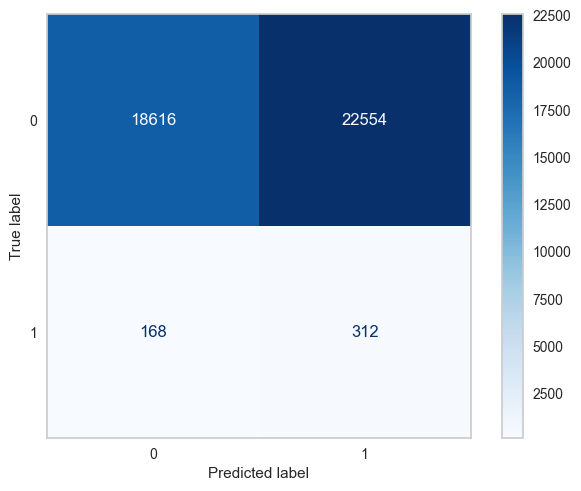

No feature importance available for sgd

Training and evaluating model: logistic_regression
Model: logistic_regression
Accuracy: 0.3609363745498199
Precision: 0.014272440066902063
Recall: 0.8
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.36      0.52     41170
           1       0.01      0.80      0.03       480

    accuracy                           0.36     41650
   macro avg       0.50      0.58      0.28     41650
weighted avg       0.98      0.36      0.52     41650



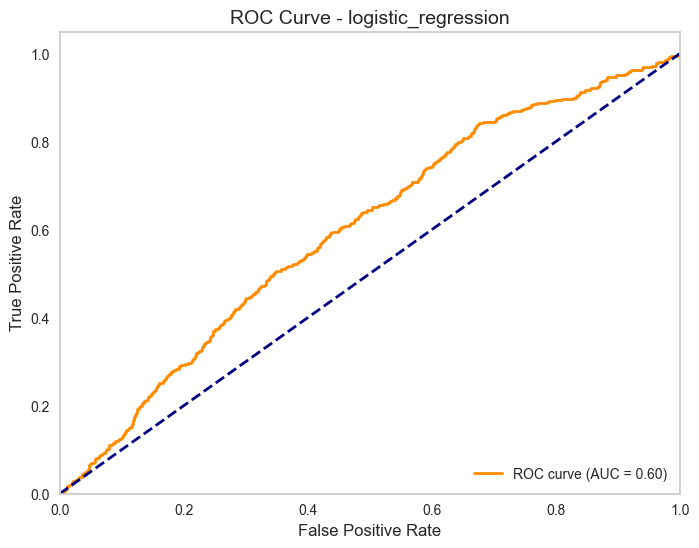

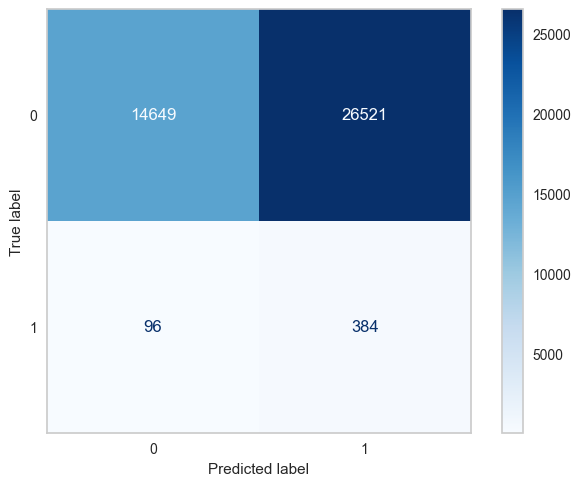

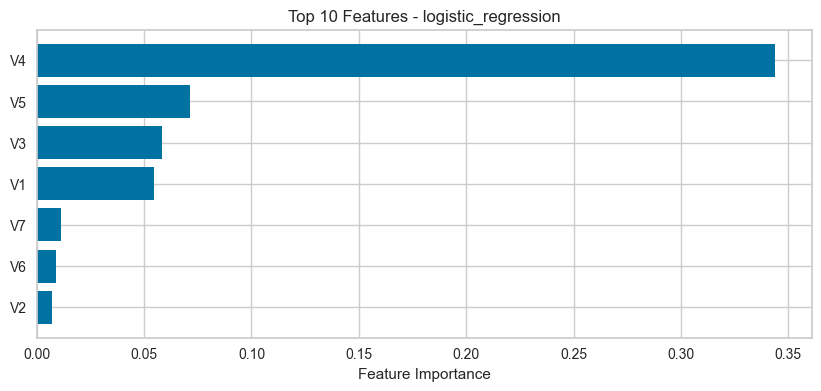

Incremental Response Rate (IRR): -0.0357
Net Incremental Revenue (NIR): $-195.75

Training and evaluating model: CatBoost
Model: CatBoost
Accuracy: 0.9861704681872749
Precision: 0.01020408163265306
Recall: 0.0020833333333333333
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     41170
           1       0.01      0.00      0.00       480

    accuracy                           0.99     41650
   macro avg       0.50      0.50      0.50     41650
weighted avg       0.98      0.99      0.98     41650



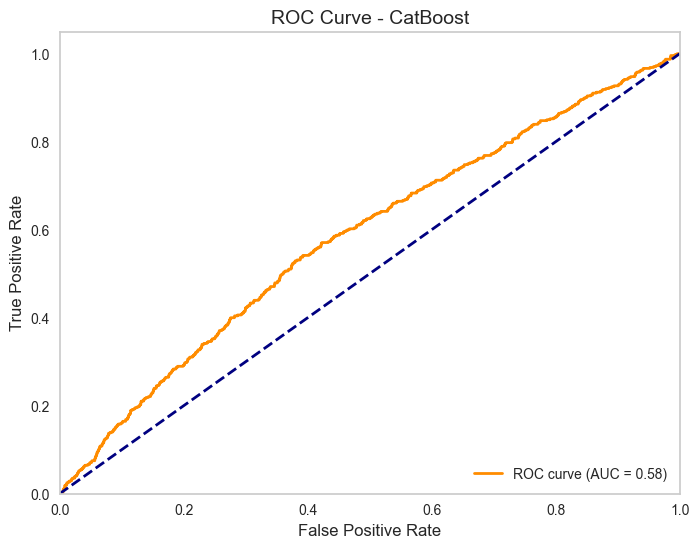

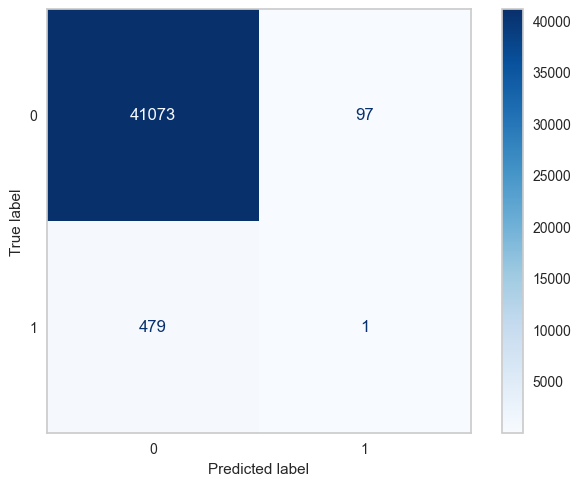

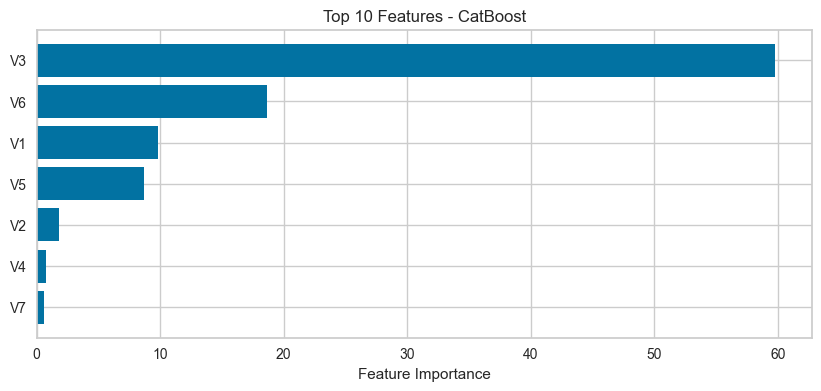

Incremental Response Rate (IRR): -0.0398
Net Incremental Revenue (NIR): $-4.70

Training and evaluating model: XGBoost
Model: XGBoost
Accuracy: 0.9827130852340936
Precision: 0.023809523809523808
Recall: 0.0125
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     41170
           1       0.02      0.01      0.02       480

    accuracy                           0.98     41650
   macro avg       0.51      0.50      0.50     41650
weighted avg       0.98      0.98      0.98     41650



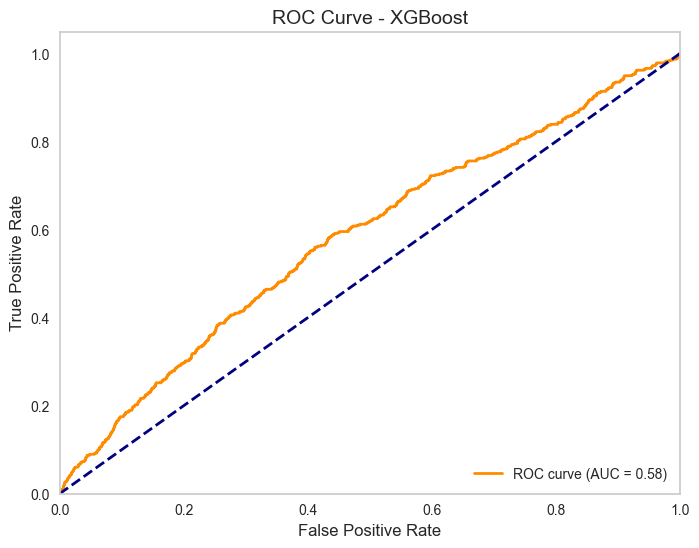

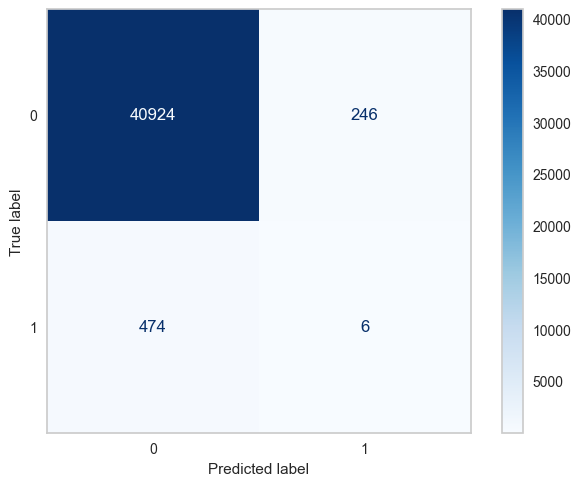

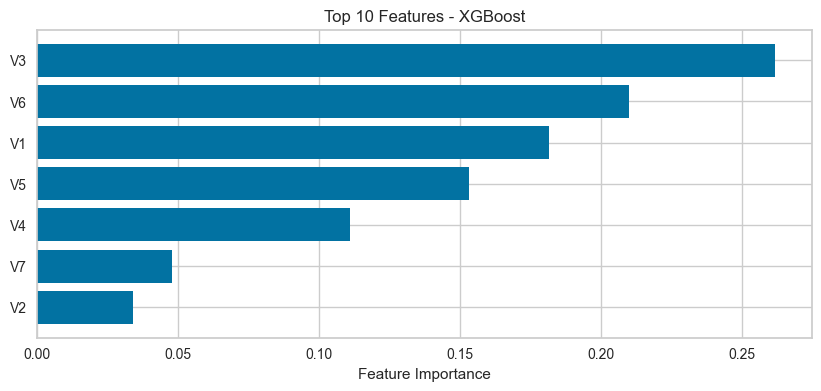

Incremental Response Rate (IRR): -0.0262
Net Incremental Revenue (NIR): $22.20

Training and evaluating model: decision_tree
Model: decision_tree
Accuracy: 0.9581272509003601
Precision: 0.008553654743390357
Recall: 0.022916666666666665
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     41170
           1       0.01      0.02      0.01       480

    accuracy                           0.96     41650
   macro avg       0.50      0.50      0.50     41650
weighted avg       0.98      0.96      0.97     41650



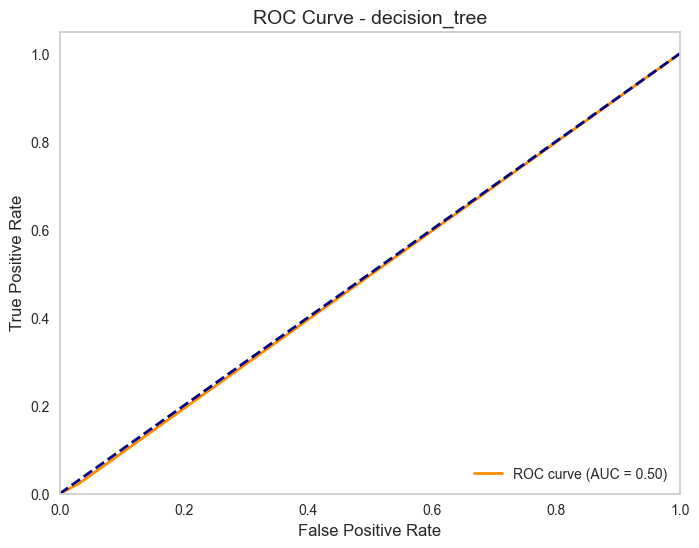

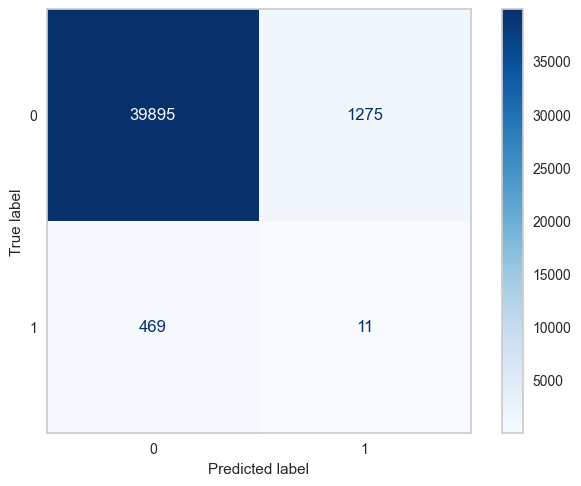

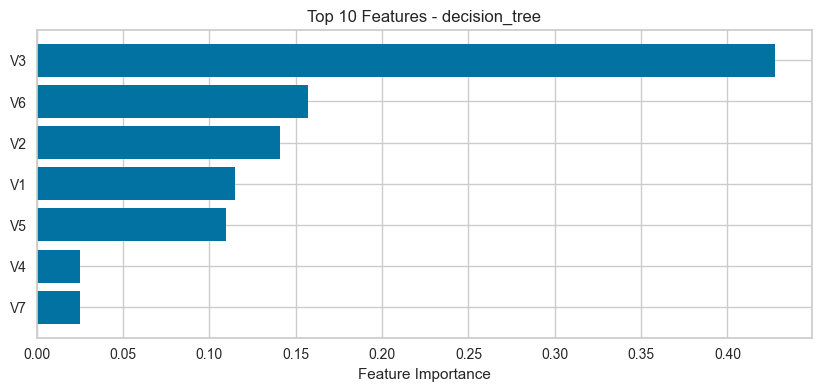

Incremental Response Rate (IRR): -0.0414
Net Incremental Revenue (NIR): $-82.90

Training and evaluating model: random_forest
Model: random_forest
Accuracy: 0.9472268907563025
Precision: 0.01414027149321267
Recall: 0.052083333333333336
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     41170
           1       0.01      0.05      0.02       480

    accuracy                           0.95     41650
   macro avg       0.50      0.50      0.50     41650
weighted avg       0.98      0.95      0.96     41650



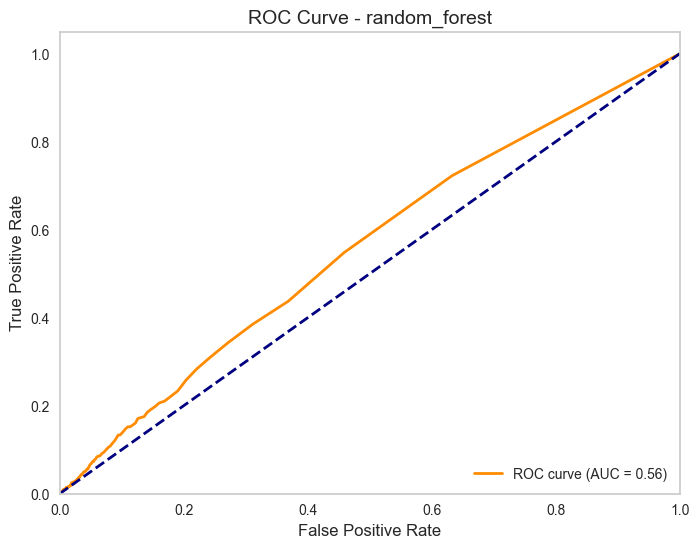

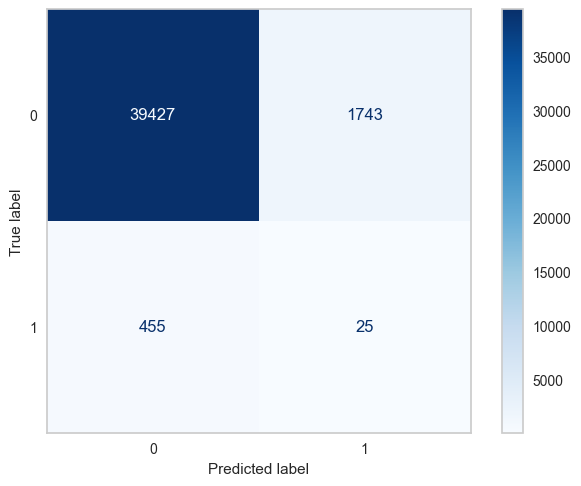

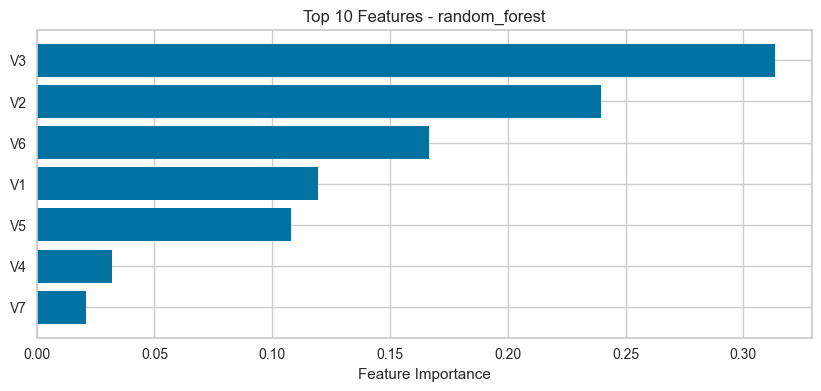

Incremental Response Rate (IRR): -0.0359
Net Incremental Revenue (NIR): $-15.20

Training and evaluating model: gaussian_naive_bayes
Model: gaussian_naive_bayes
Accuracy: 0.38554621848739495
Precision: 0.01401145688187026
Recall: 0.7541666666666667
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.38      0.55     41170
           1       0.01      0.75      0.03       480

    accuracy                           0.39     41650
   macro avg       0.50      0.57      0.29     41650
weighted avg       0.98      0.39      0.54     41650



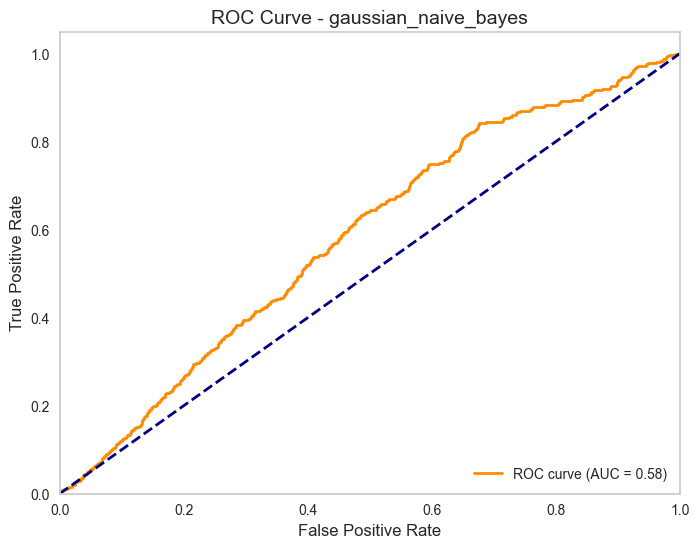

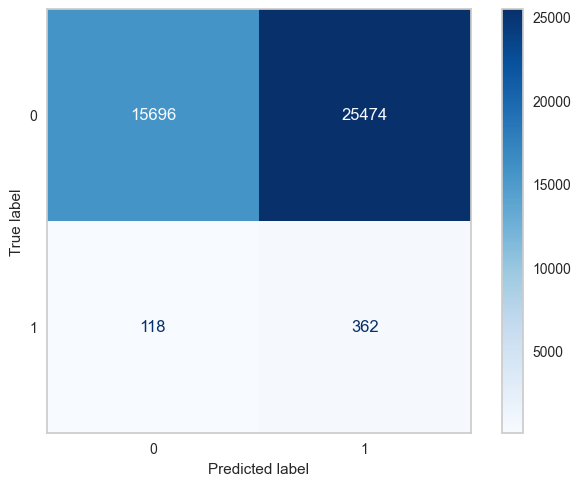

No feature importance available for gaussian_naive_bayes
Incremental Response Rate (IRR): -0.0360
Net Incremental Revenue (NIR): $-255.40

Training and evaluating model: k_nearest_neighbors
Model: k_nearest_neighbors
Accuracy: 0.8703001200480192
Precision: 0.01536037810161481
Recall: 0.1625
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     41170
           1       0.02      0.16      0.03       480

    accuracy                           0.87     41650
   macro avg       0.50      0.52      0.48     41650
weighted avg       0.98      0.87      0.92     41650



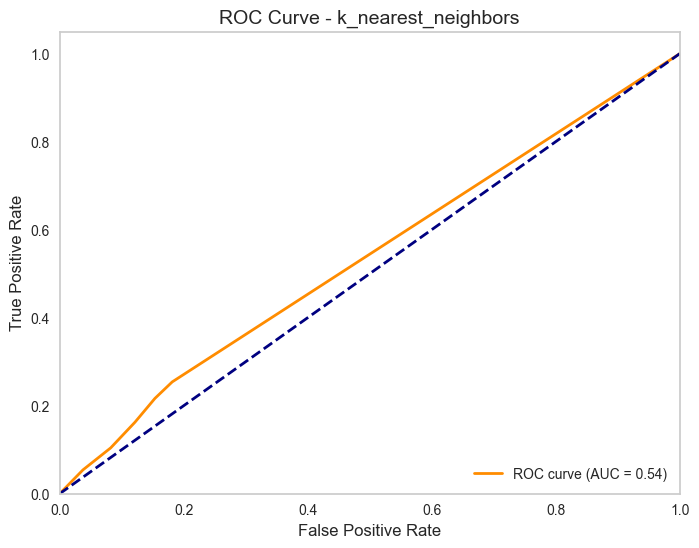

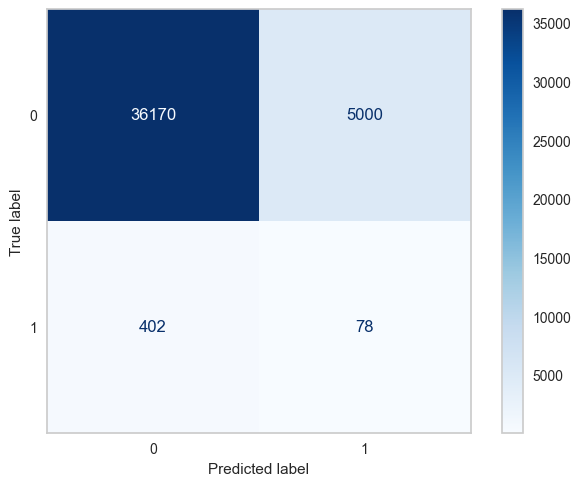

No feature importance available for k_nearest_neighbors
Incremental Response Rate (IRR): -0.0346
Net Incremental Revenue (NIR): $18.30

Training and evaluating model: gradient_boosting
Model: gradient_boosting
Accuracy: 0.8214645858343337
Precision: 0.016138007790762382
Recall: 0.24166666666666667
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     41170
           1       0.02      0.24      0.03       480

    accuracy                           0.82     41650
   macro avg       0.50      0.53      0.47     41650
weighted avg       0.98      0.82      0.89     41650



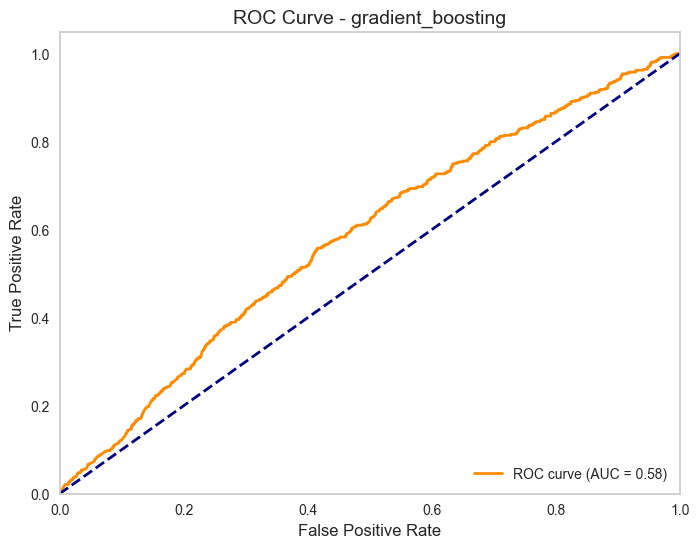

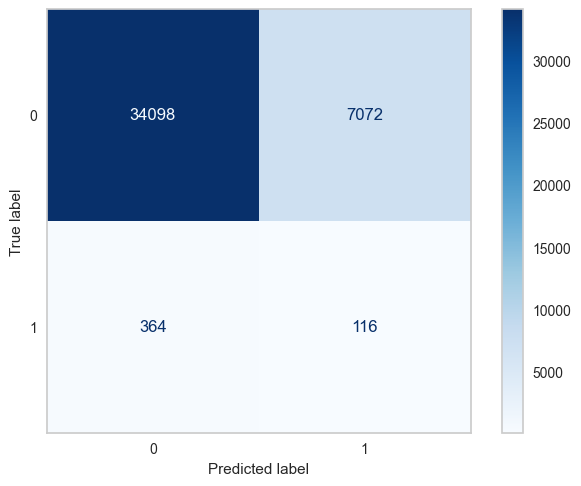

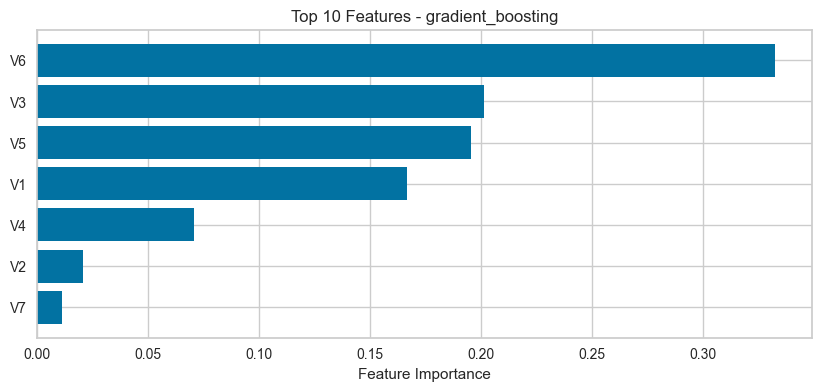

Incremental Response Rate (IRR): -0.0339
Net Incremental Revenue (NIR): $81.80

Training and evaluating model: linear_discriminant_analysis
Model: linear_discriminant_analysis
Accuracy: 0.35853541416566626
Precision: 0.014219588965006481
Recall: 0.8
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.35      0.52     41170
           1       0.01      0.80      0.03       480

    accuracy                           0.36     41650
   macro avg       0.50      0.58      0.27     41650
weighted avg       0.98      0.36      0.52     41650



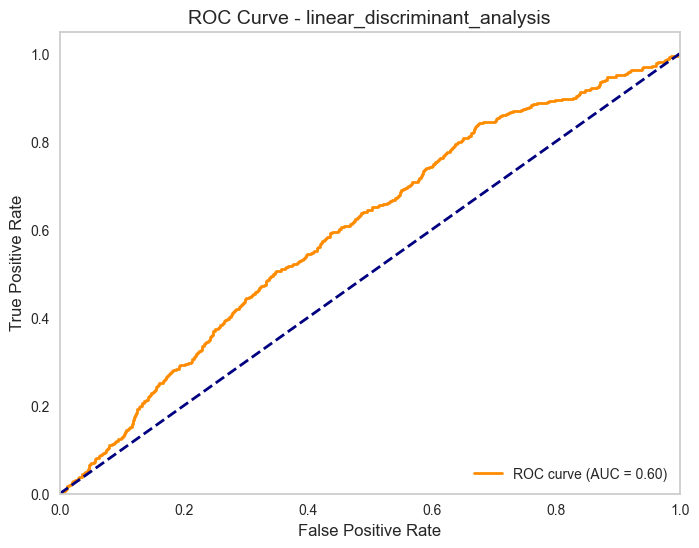

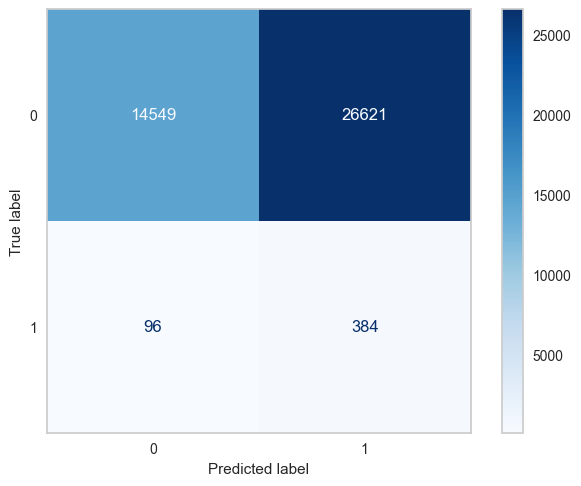

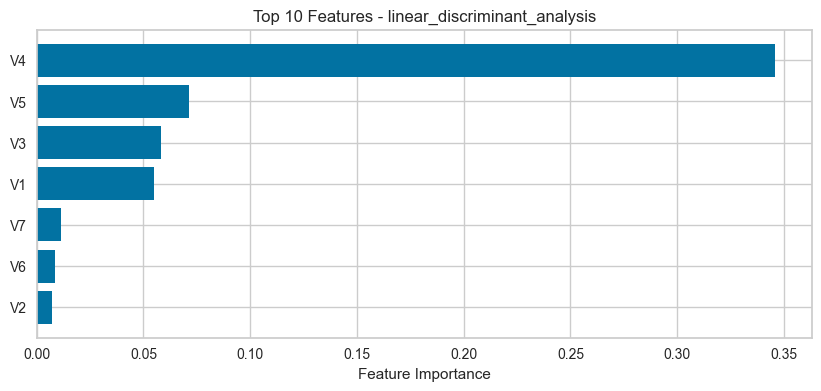

Incremental Response Rate (IRR): -0.0358
Net Incremental Revenue (NIR): $-210.75

Training and evaluating model: bagging
Model: bagging
Accuracy: 0.9705642256902761
Precision: 0.005305039787798408
Recall: 0.008333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     41170
           1       0.01      0.01      0.01       480

    accuracy                           0.97     41650
   macro avg       0.50      0.50      0.50     41650
weighted avg       0.98      0.97      0.97     41650



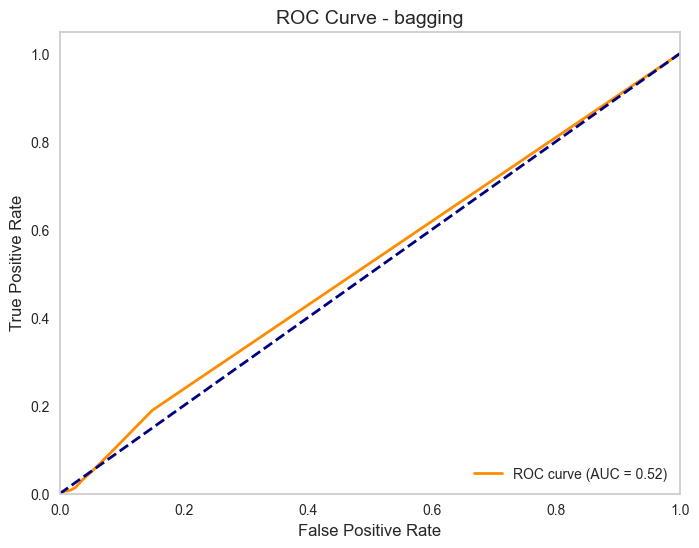

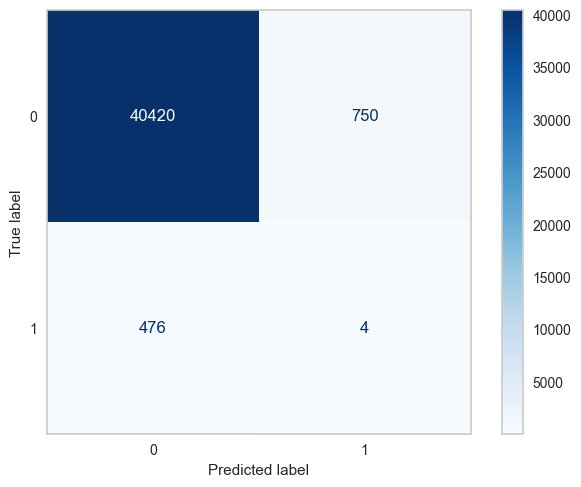

No feature importance available for bagging
Incremental Response Rate (IRR): -0.0447
Net Incremental Revenue (NIR): $-73.10

Training and evaluating model: neural_network


c:\Users\ikiga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Model: neural_network
Accuracy: 0.724873949579832
Precision: 0.01459014943850031
Recall: 0.34375
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84     41170
           1       0.01      0.34      0.03       480

    accuracy                           0.72     41650
   macro avg       0.50      0.54      0.43     41650
weighted avg       0.98      0.72      0.83     41650



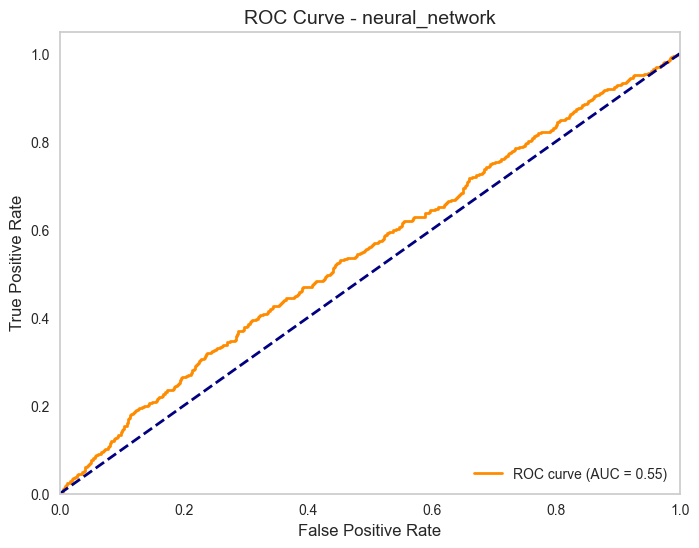

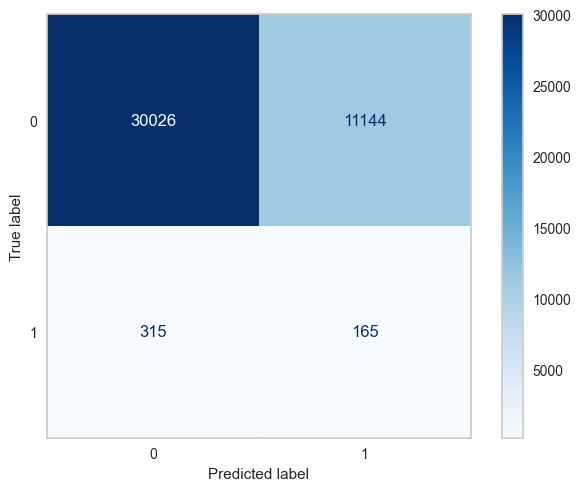

No feature importance available for neural_network
Incremental Response Rate (IRR): -0.0354
Net Incremental Revenue (NIR): $-46.35

Training and evaluating model: adaboost


c:\Users\ikiga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Model: adaboost
Accuracy: 0.7076590636254502
Precision: 0.01725276539541027
Recall: 0.4354166666666667
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83     41170
           1       0.02      0.44      0.03       480

    accuracy                           0.71     41650
   macro avg       0.50      0.57      0.43     41650
weighted avg       0.98      0.71      0.82     41650



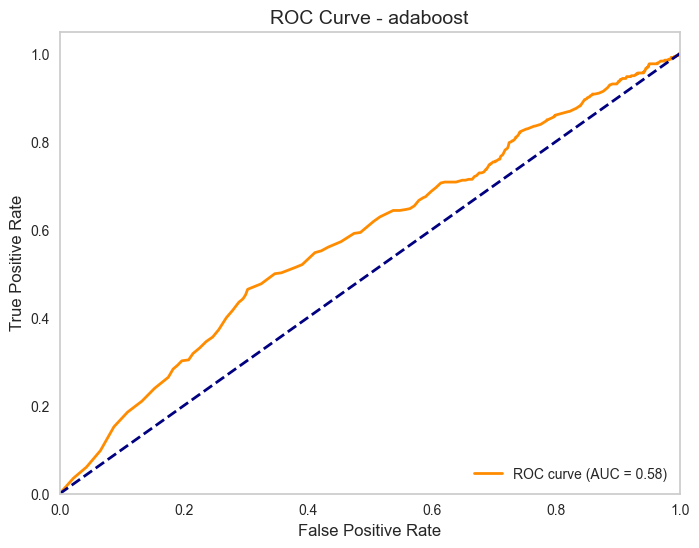

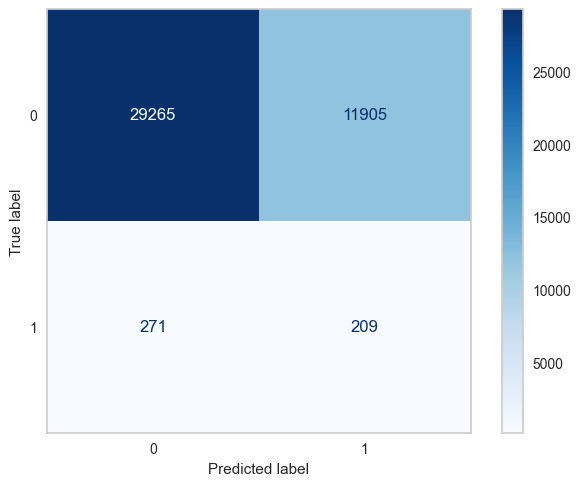

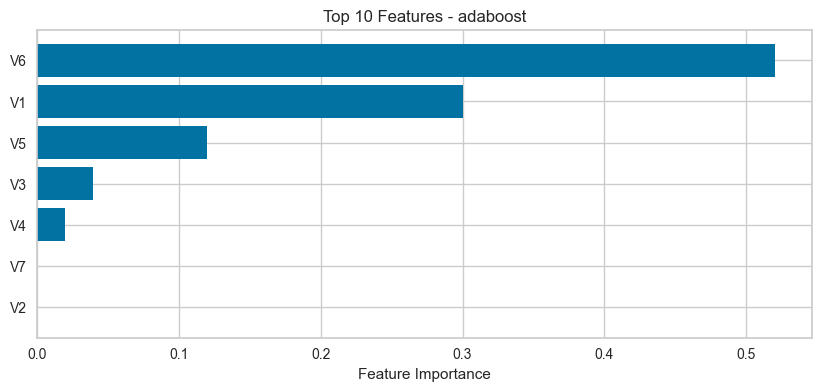

Incremental Response Rate (IRR): -0.0327
Net Incremental Revenue (NIR): $272.90

Training and evaluating model: extra_trees
Model: extra_trees
Accuracy: 0.9505882352941176
Precision: 0.014760147601476014
Recall: 0.05
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     41170
           1       0.01      0.05      0.02       480

    accuracy                           0.95     41650
   macro avg       0.50      0.51      0.50     41650
weighted avg       0.98      0.95      0.96     41650



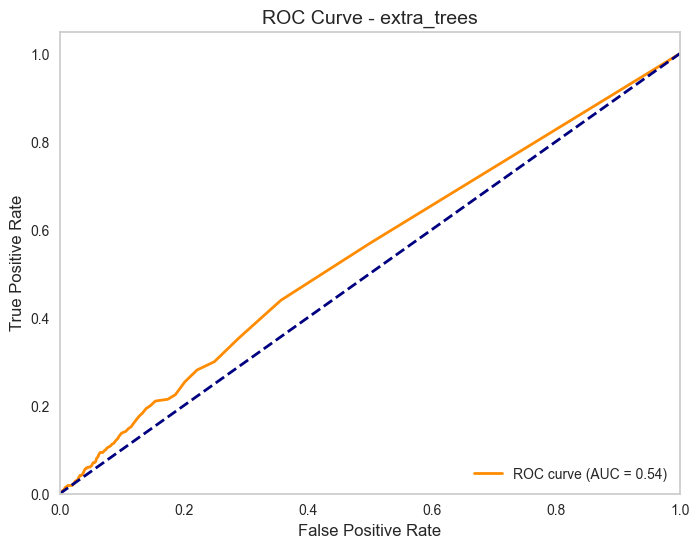

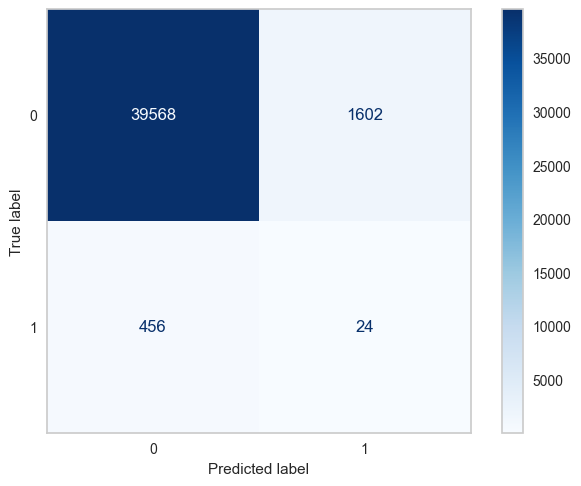

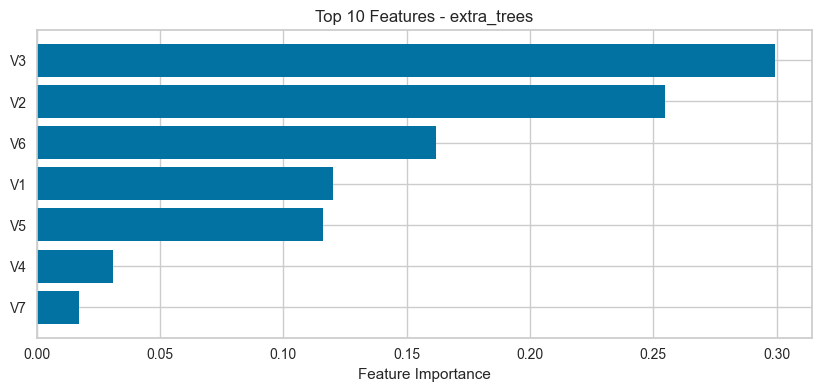

Incremental Response Rate (IRR): -0.0352
Net Incremental Revenue (NIR): $-3.90


In [10]:
classifiers = {
    'sgd':SGDClassifier(random_state=42,loss='perceptron'),
    'logistic_regression':LogisticRegression(random_state=42),
    "CatBoost": CatBoostClassifier(silent=True),
    'XGBoost': XGBClassifier(random_state=42),
    'decision_tree':DecisionTreeClassifier(random_state=42),
    'random_forest':RandomForestClassifier(random_state=42),
    'gaussian_naive_bayes':GaussianNB(),
    'k_nearest_neighbors':KNeighborsClassifier(),
    'gradient_boosting':GradientBoostingClassifier(random_state=42),
    'linear_discriminant_analysis':LinearDiscriminantAnalysis(),
    'bagging':BaggingClassifier(random_state=42),
    'neural_network':MLPClassifier(random_state=42),
    'adaboost':AdaBoostClassifier(random_state=42),
    'extra_trees':ExtraTreesClassifier(random_state=42),
}

results = []

for model_name, model in classifiers.items():
    print(f"\nTraining and evaluating model: {model_name}")

    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    print(f"Model: {model_name}")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

    plot_roc_curve(model, model_name, X_test_scaled, y_test)

    print_confusion_matrix_display(model, y_test, y_pred)

    feat_importance_plot(model, model_name)

    if y_proba is not None:
        irr, nir = calculate_incremental_metrics(
            y_actual=y_test,
            y_pred=y_pred,
            baseline_conversion_rate=baseline_conversion_rate,
            promotion_cost=promotion_cost,
            purchase_revenue=purchase_revenue
        )
        print(f"Incremental Response Rate (IRR): {irr:.4f}")
        print(f"Net Incremental Revenue (NIR): ${nir:.2f}")
    else: 
        irr, nir = None, None

    results.append({
        'Model': model_name,
        'Accuracy': acc * 100,
        'Precision': prec,
        'Recall': rec,
        'IRR': irr,
        'NIR': nir
    })

### Model Accuracy Output 

In [11]:
results_df = pd.DataFrame(results)
results_df.sort_values('Accuracy',  ascending=False)

,Model,Accuracy,Precision,Recall,IRR,NIR
2,CatBoost,98.617047,0.010204,0.002083,-0.039796,-4.70
3,XGBoost,98.271309,0.023810,0.012500,-0.026190,22.20
10,bagging,97.056423,0.005305,0.008333,-0.044695,-73.10
4,decision_tree,95.812725,0.008554,0.022917,-0.041446,-82.90
13,extra_trees,95.058824,0.014760,0.050000,-0.035240,-3.90
5,random_forest,94.722689,0.014140,0.052083,-0.035860,-15.20
7,k_nearest_neighbors,87.030012,0.015360,0.162500,-0.034640,18.30
8,gradient_boosting,82.146459,0.016138,0.241667,-0.033862,81.80
11,neural_network,72.487395,0.014590,0.343750,-0.035410,-46.35
12,adaboost,70.765906,0.017253,0.435417,-0.032747,272.90


## Validaate Strategy

As we can see in the Model output XGBoost would likely be the most well-rounded choice, considering both accuracy and NIR, while AdaBoost could be chosen if the priority is maximizing revenue despite some trade-off in accuracy.

Now, Implement a function to compare the predicted and actual promotion effectiveness by analyzing quadrants of predicted vs. actual outcomes.

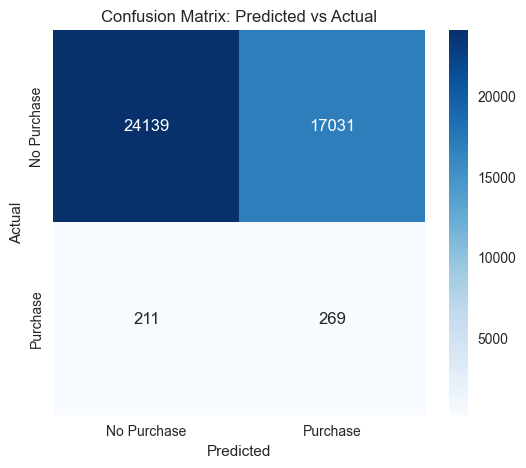

Incremental Response Rate (IRR): 0.0069
Net Incremental Revenue (NIR): $-2015.00

Performance compared to baseline:
Baseline IRR: 0.0500
Baseline NIR: $0.00


In [18]:
def promotion_strategy(model, X_test, y_test, threshold=0.1):
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= threshold).astype(int)

    result_data = X_test.copy()
    result_data['purchase'] = y_test 
    result_data['prediction'] = y_pred 
    
    confusion = confusion_matrix(y_test, y_pred)
    plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=["No Purchase", "Purchase"], yticklabels=["No Purchase", "Purchase"])
    plt.title("Confusion Matrix: Predicted vs Actual")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    treatment_data = result_data[result_data['prediction'] == 1]
    control_data = result_data[result_data['prediction'] == 0]

    irr = (treatment_data['purchase'].mean() - control_data['purchase'].mean())
    nir = (purchase_revenue * treatment_data['purchase'].sum() - promotion_cost * len(treatment_data)) - (purchase_revenue * control_data['purchase'].sum())
    
    print(f"Incremental Response Rate (IRR): {irr:.4f}")
    print(f"Net Incremental Revenue (NIR): ${nir:.2f}")


def test_results(model, X_test, y_test):
    # Run promotion strategy validation
    promotion_strategy(model, X_test, y_test)
    
    # Compare overall IRR and NIR to baseline
    baseline_irr = 0.05  # Assuming baseline IRR from prior testing
    baseline_nir = 0  # Assuming baseline NIR (no promotion cost)
    
    # Compare current model performance to baseline
    print(f"\nPerformance compared to baseline:")
    print(f"Baseline IRR: {baseline_irr:.4f}")
    print(f"Baseline NIR: ${baseline_nir:.2f}")


best_model = classifiers['XGBoost']  # Replace with your model
test_results(best_model, X_test_scaled, y_test)

